# Superstore Sales Analysis

## Project Overview
The goal of this project is to analyze sales data from a US-based retail store to discover which products, categories, and regions generate the most revenue and profit, and to understand customer purchasing behavior across different time periods.

---

## Dataset Description
| | |
|---|---|
| **File** | project_store.csv |
| **Rows** | 4,922 orders |
| **Columns** | 28 columns |
| **Period** | 2015 – 2018 |
| **Key columns** | Sales, Profit, Discount, Quantity, Category, Region, Segment, Ship Mode, Financial Status, Shipping Status |

---

## Questions We Want to Answer
| # | Question |
|---|----------|
| Q1 | Which product category has the highest total sales? |
| Q2 | Which region generates the most revenue? |
| Q3 | What are the top-selling sub-categories? |
| Q4 | Are sales growing year over year? |
| Q5 | Which customer segment contributes the most to sales? |
| Q6 | Which shipping method is the fastest and most popular? |
| Q7 | Which month records the highest sales? |
| Q8 | How does category performance vary across regions? |
| Q9 | What percentage of orders are profitable vs loss-making? |
| Q10 | How does discount affect profit? |


## Step 1 — Upload the Dataset

In [8]:
from google.colab import files
uploaded = files.upload()

Saving project store.csv to project store (1).csv


In [12]:
import os
print(os.listdir())

['.config', 'project store (1).csv', 'project store.csv', 'sample_data']


## Step 2 — Import Libraries

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
BLUE   = '#4C72B0'
GREEN  = '#55A868'
ORANGE = '#C44E52'
PURPLE = '#8172B2'
TEAL   = '#64B5CD'

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 3 — Load the Data

In [16]:
df = pd.read_csv('project store (1).csv')
print(f"Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 4,922 rows, 28 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Discount,Profit,Profit Margin,Financial Status,Days to Ship,Shipping Status,Year,MonthNumber,MonthName
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,261.96,0.0,104.78,0.4,Profit,3,Average,2017,11,November
1,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,14.62,0.0,5.85,0.4,Profit,4,Average,2017,6,June
2,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.58,0.0,383.03,0.4,Profit,7,Delayed,2016,10,October
3,6,CA-2015-115812,6/9/2015,6/14/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,48.86,0.1,14.66,0.3,Profit,5,Average,2015,6,June
4,13,CA-2018-114412,4/15/2018,4/20/2018,Standard Class,AA-10480,Andrew Allen,Consumer,United States,Concord,...,15.55,0.0,6.22,0.4,Profit,5,Average,2018,4,April


## Step 4 — Data Cleaning

Before starting the analysis, we check the quality of the data:
- Are there any **missing values**?
- Are there any **duplicate rows**?
- Are the **data types** correct?
- Do the **date columns** need to be converted?


In [17]:
# check missing values
print("Missing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")
print()

# check duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")
print()

# check data types
print("Data types:")
print(df.dtypes)

Missing values per column:
No missing values found.

Duplicate rows: 0

Data types:
Row ID                int64
Order ID             object
Order Date           object
Ship Date            object
Ship Mode            object
Customer ID          object
Customer Name        object
Segment              object
Country              object
City                 object
State                object
Postal Code           int64
Region               object
Product ID           object
Category             object
Sub-Category         object
Product Name         object
Quantity              int64
Sales               float64
Discount            float64
Profit              float64
Profit Margin       float64
Financial Status     object
Days to Ship          int64
Shipping Status      object
Year                  int64
MonthNumber           int64
MonthName            object
dtype: object


In [19]:
# convert date columns to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='%m/%d/%Y')

# rename columns for consistency
df.rename(columns={'MonthNumber': 'Month', 'Days to Ship': 'Shipping Days'}, inplace=True)

print("Data cleaning completed.")
print(f"Missing values remaining: {df.isnull().sum().sum()}")
print(f"Date range: {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")

Data cleaning completed.
Missing values remaining: 0
Date range: 2015-01-03 to 2018-12-30


## Step 5 — Exploratory Data Analysis (EDA)

In [20]:
print("=== Dataset Summary ===")
print(f"Total Sales        : ${df['Sales'].sum():,.2f}")
print(f"Total Profit       : ${df['Profit'].sum():,.2f}")
print(f"Total Orders       : {df['Order ID'].nunique():,}")
print(f"Unique Customers   : {df['Customer ID'].nunique():,}")
print(f"Avg Order Value    : ${df.groupby('Order ID')['Sales'].sum().mean():,.2f}")
print(f"Avg Discount       : {df['Discount'].mean()*100:.1f}%")
print(f"Profitable Orders  : {(df['Financial Status']=='Profit').sum():,}")
print(f"Loss Orders        : {(df['Financial Status']=='Loss').sum():,}")
print()
df.describe().round(2)

=== Dataset Summary ===
Total Sales        : $1,082,910.83
Total Profit       : $259,310.84
Total Orders       : 4,922
Unique Customers   : 793
Avg Order Value    : $220.01
Avg Discount       : 16.6%
Profitable Orders  : 4,173
Loss Orders        : 749



,Row ID,Order Date,Ship Date,Postal Code,Quantity,Sales,Discount,Profit,Profit Margin,Shipping Days,Year,Month
count,4922.00,4922,4922,4922.00,4922.00,4922.00,4922.00,4922.00,4922.00,4922.00,4922.00,4922.00
mean,4958.48,2017-05-09 04:28:51.978870016,2017-05-13 03:29:10.995530496,55473.39,7.52,220.01,0.17,52.68,0.23,3.96,2016.75,7.82
min,1.00,2015-01-03 00:00:00,2015-01-07 00:00:00,1040.00,1.00,0.56,0.00,-3359.99,-0.40,0.00,2015.00,1.00
25%,2508.25,2016-06-01 00:00:00,2016-06-05 00:00:00,23464.00,4.00,16.26,0.00,2.19,0.10,3.00,2016.00,5.00
50%,4975.50,2017-07-10 00:00:00,2017-07-14 00:00:00,60082.50,8.00,51.65,0.10,10.37,0.30,4.00,2017.00,9.00
75%,7421.75,2018-05-20 00:00:00,2018-05-24 18:00:00,90008.00,11.00,201.58,0.30,47.30,0.40,5.00,2018.00,11.00
max,9797.00,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.00,14.00,11199.97,0.80,4479.99,0.40,7.00,2018.00,12.00
std,2835.96,NaN,NaN,31991.19,4.04,555.15,0.24,193.89,0.24,1.74,1.12,3.29


## Q1 — Which product category has the highest total sales?

We have 3 main categories: Furniture, Office Supplies, and Technology.


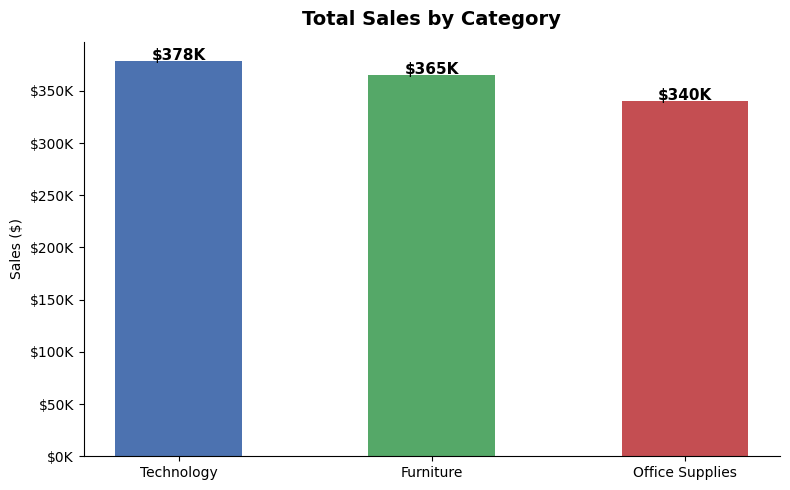

  Technology: $378,205 (34.9%)
  Furniture: $364,767 (33.7%)
  Office Supplies: $339,939 (31.4%)


In [21]:
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(cat_sales.index, cat_sales.values, color=[BLUE, GREEN, ORANGE], width=0.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1500,
            f'${bar.get_height() / 1000:.0f}K', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Total Sales by Category', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

for cat, val in cat_sales.items():
    print(f"  {cat}: ${val:,.0f} ({val/cat_sales.sum()*100:.1f}%)")

### Insight
Technology is the top-performing category with the highest total sales, followed by Furniture and Office Supplies. This suggests customers are spending more on high-value tech products. The store should prioritize expanding its technology product range and running targeted promotions in this category.


## Q2 — Which region generates the most revenue?

The dataset covers 4 regions: West, East, Central, and South.


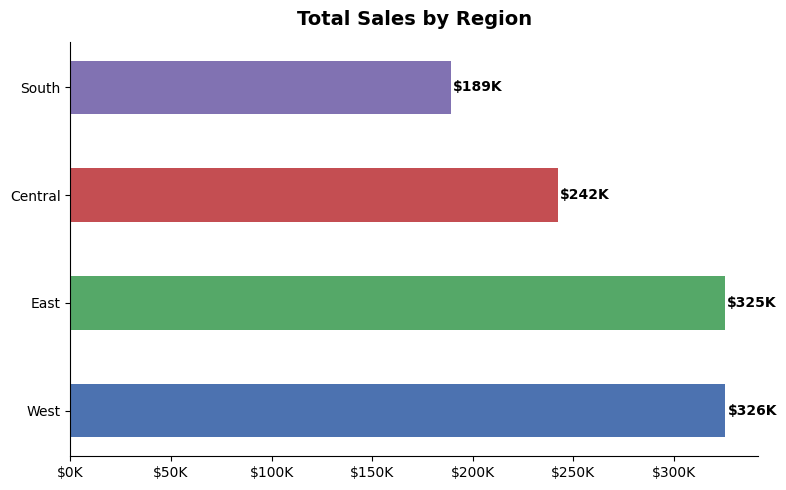

  West: $325,811
  East: $325,375
  Central: $242,473
  South: $189,251


In [22]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(region_sales.index, region_sales.values, color=[BLUE, GREEN, ORANGE, PURPLE], height=0.5)
for bar in bars:
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height() / 2,
            f'${bar.get_width() / 1000:.0f}K', va='center', fontsize=10, fontweight='bold')
ax.set_title('Total Sales by Region', fontsize=14, fontweight='bold', pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

for reg, val in region_sales.items():
    print(f"  {reg}: ${val:,.0f}")

### Insight
The West region leads in total sales, while the South is the weakest. This performance gap suggests an opportunity to invest more in marketing and sales efforts in the South region to boost revenue.


## Q3 — What are the top-selling sub-categories?

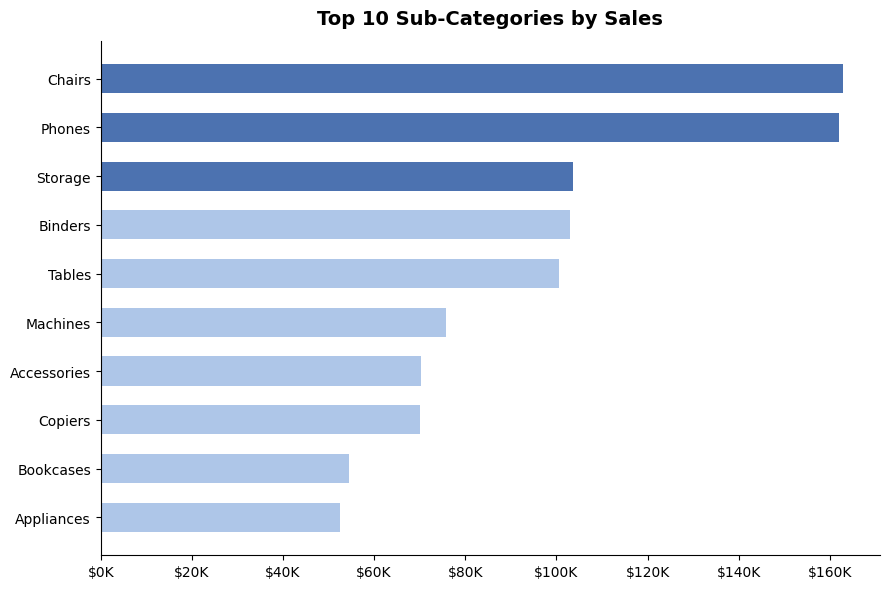

Top 5 sub-categories:
  1. Chairs: $162,877
  2. Phones: $161,995
  3. Storage: $103,685
  4. Binders: $103,016
  5. Tables: $100,529


In [23]:
subcat = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
top10  = subcat.head(10)

fig, ax = plt.subplots(figsize=(9, 6))
bar_colors = [BLUE if i < 3 else '#aec6e8' for i in range(len(top10))]
ax.barh(top10.index[::-1], top10.values[::-1], color=bar_colors[::-1], height=0.6)
ax.set_title('Top 10 Sub-Categories by Sales', fontsize=14, fontweight='bold', pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print("Top 5 sub-categories:")
for i, (sc, val) in enumerate(subcat.head(5).items(), 1):
    print(f"  {i}. {sc}: ${val:,.0f}")

### Insight
The top sub-categories are high-ticket items which explains their revenue dominance. Low-performing sub-categories contribute very little to total sales, so the store might reconsider the budget allocated to them.


## Q4 — Are sales growing year over year?

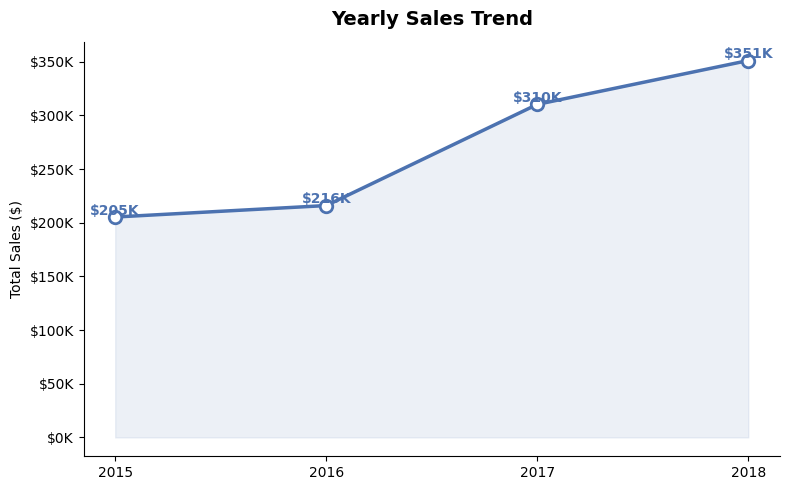

Overall growth 2015 to 2018: 71.0%
  2015: $205,363
  2016: $216,049
  2017: $310,313
  2018: $351,186


In [24]:
yr = df.groupby('Year')['Sales'].sum()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(yr.index, yr.values, color=BLUE, linewidth=2.5,
        marker='o', markersize=9, markerfacecolor='white', markeredgecolor=BLUE, markeredgewidth=2)
ax.fill_between(yr.index, yr.values, alpha=0.1, color=BLUE)
for x, y in zip(yr.index, yr.values):
    ax.text(x, y + 2000, f'${y/1000:.0f}K', ha='center', fontsize=10, fontweight='bold', color=BLUE)
ax.set_title('Yearly Sales Trend', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.spines[['top', 'right']].set_visible(False)
ax.set_xticks(yr.index)
plt.tight_layout()
plt.show()

growth = (yr.iloc[-1] - yr.iloc[0]) / yr.iloc[0] * 100
print(f"Overall growth 2015 to 2018: {growth:.1f}%")
for y, v in yr.items():
    print(f"  {y}: ${v:,.0f}")

### Insight
Sales have grown consistently over the 4-year period, indicating a healthy and expanding business. This upward trend confirms the store is gaining more customers and increasing order values over time.


## Q5 — Which customer segment contributes the most to sales?

Segments: Consumer, Corporate, Home Office


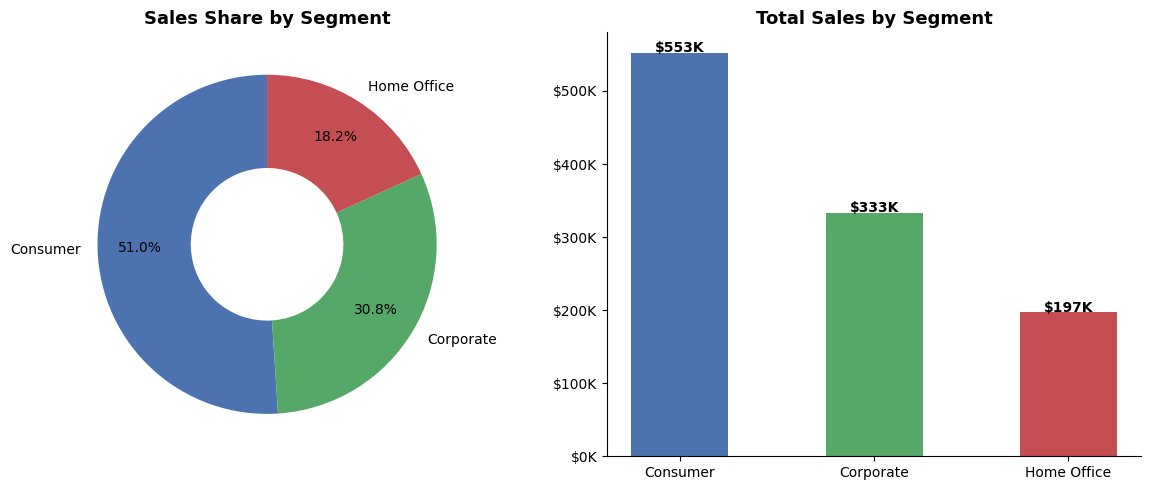

  Consumer: $552,594 (51.0%)
  Corporate: $333,366 (30.8%)
  Home Office: $196,950 (18.2%)


In [25]:
seg = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.pie(seg.values, labels=seg.index, colors=[BLUE, GREEN, ORANGE],
        autopct='%1.1f%%', startangle=90, wedgeprops={'width': 0.55},
        pctdistance=0.75, textprops={'fontsize': 10})
ax1.set_title('Sales Share by Segment', fontsize=13, fontweight='bold')

ax2.bar(seg.index, seg.values, color=[BLUE, GREEN, ORANGE], width=0.5)
for i, (s, v) in enumerate(seg.items()):
    ax2.text(i, v + 1000, f'${v/1000:.0f}K', ha='center', fontsize=10, fontweight='bold')
ax2.set_title('Total Sales by Segment', fontsize=13, fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax2.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

for s, v in seg.items():
    print(f"  {s}: ${v:,.0f} ({v/seg.sum()*100:.1f}%)")

### Insight
The Consumer segment is the largest contributor to total sales, making it the most important customer group. The store should focus its loyalty programs and promotions on Consumer customers, while also developing strategies to grow the Corporate segment.


## Q6 — Which shipping method is the fastest and most popular?

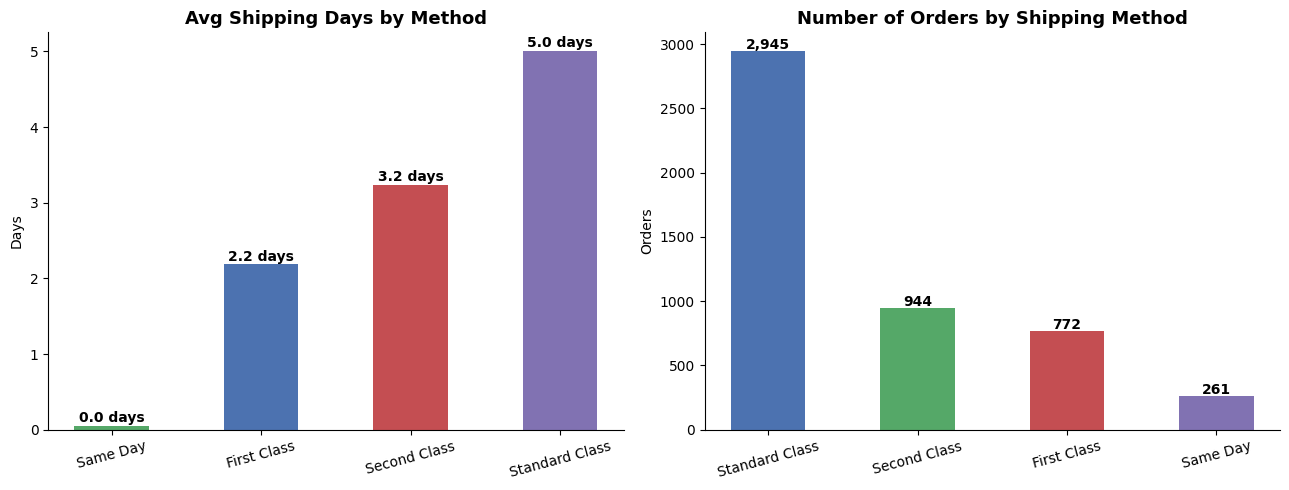

Fastest : Same Day (0.0 days)
Slowest : Standard Class (5.0 days)
Most used: Standard Class (2,945 orders)

Shipping Status breakdown:
Shipping Status
Average    2946
Fast       1089
Delayed     887
Name: count, dtype: int64


In [26]:
ship_avg   = df.groupby('Ship Mode')['Shipping Days'].mean().sort_values()
ship_count = df['Ship Mode'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
bars1 = ax1.bar(ship_avg.index, ship_avg.values, color=[GREEN, BLUE, ORANGE, PURPLE], width=0.5)
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             f'{bar.get_height():.1f} days', ha='center', fontsize=10, fontweight='bold')
ax1.set_title('Avg Shipping Days by Method', fontsize=13, fontweight='bold')
ax1.set_ylabel('Days')
ax1.tick_params(axis='x', rotation=15)
ax1.spines[['top', 'right']].set_visible(False)

bars2 = ax2.bar(ship_count.index, ship_count.values, color=[BLUE, GREEN, ORANGE, PURPLE], width=0.5)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
             f'{bar.get_height():,}', ha='center', fontsize=10, fontweight='bold')
ax2.set_title('Number of Orders by Shipping Method', fontsize=13, fontweight='bold')
ax2.set_ylabel('Orders')
ax2.tick_params(axis='x', rotation=15)
ax2.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Fastest : {ship_avg.idxmin()} ({ship_avg.min():.1f} days)")
print(f"Slowest : {ship_avg.idxmax()} ({ship_avg.max():.1f} days)")
print(f"Most used: {ship_count.idxmax()} ({ship_count.max():,} orders)")
print()
print("Shipping Status breakdown:")
print(df['Shipping Status'].value_counts())

### Insight
Standard Class is the most used shipping method despite being the slowest, likely because it is the cheapest option. For high-value orders, the store could promote First Class shipping as an upgrade to improve customer satisfaction.


## Q7 — Which month records the highest sales?

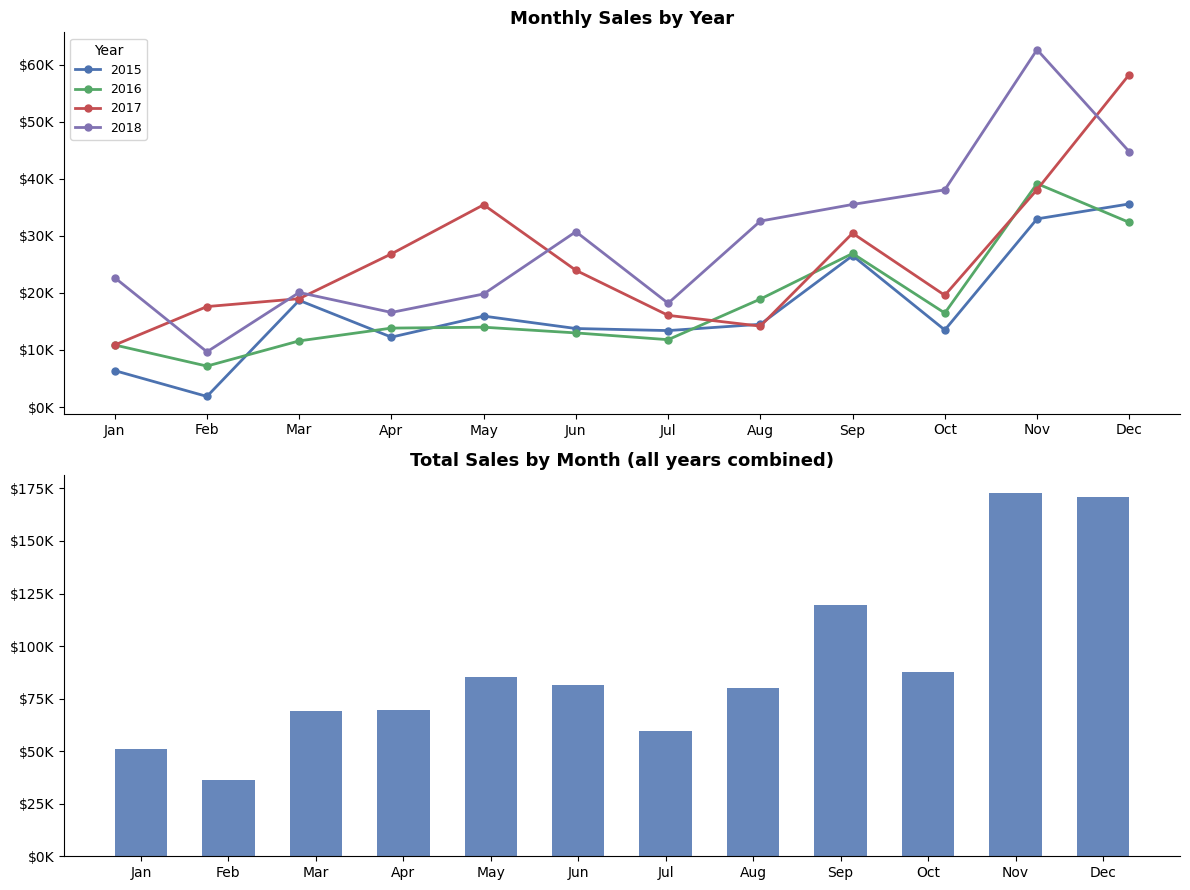

Highest month: Nov with $172,808 in total sales


In [27]:
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_year   = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
mon_total    = df.groupby('Month')['Sales'].sum().reindex(range(1, 13))
year_colors  = [BLUE, GREEN, ORANGE, PURPLE]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9))
for i, yr_val in enumerate(sorted(df['Year'].unique())):
    subset = month_year[month_year['Year'] == yr_val]
    ax1.plot(subset['Month'], subset['Sales'], label=str(yr_val),
             color=year_colors[i], linewidth=2, marker='o', markersize=5)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_labels)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax1.legend(title='Year', fontsize=9)
ax1.set_title('Monthly Sales by Year', fontsize=13, fontweight='bold')
ax1.spines[['top', 'right']].set_visible(False)

ax2.bar(range(1, 13), mon_total.values, color=BLUE, width=0.6, alpha=0.85)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(month_labels)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax2.set_title('Total Sales by Month (all years combined)', fontsize=13, fontweight='bold')
ax2.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

top_m = mon_total.idxmax()
print(f"Highest month: {month_labels[top_m-1]} with ${mon_total[top_m]:,.0f} in total sales")

### Insight
November consistently records the highest sales across all years, which strongly aligns with the Black Friday and holiday shopping season. The store should plan inventory and staffing ahead of November to avoid stockouts and delays during the peak demand period.


## Q8 — How does category performance vary across regions?

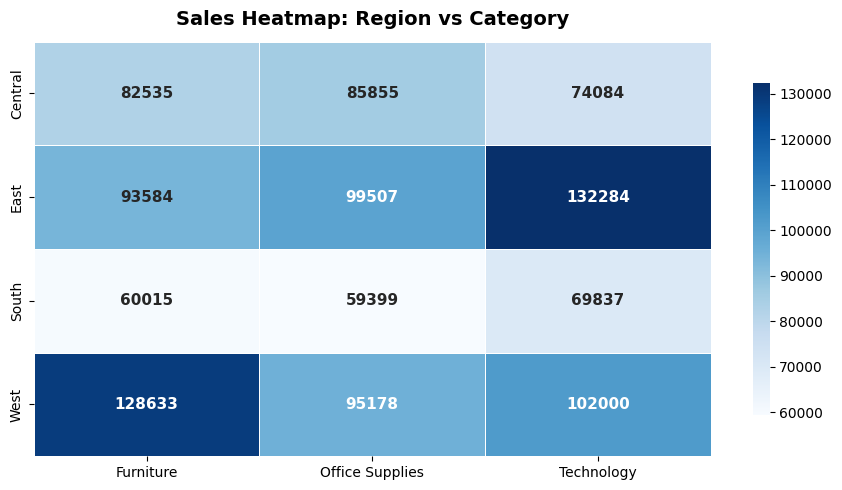

Top category per region:
  Central: Office Supplies ($85,855)
  East: Technology ($132,284)
  South: Technology ($69,837)
  West: Furniture ($128,633)


In [28]:
hm = df.pivot_table(values='Sales', index='Region', columns='Category', aggfunc='sum')

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(hm, ax=ax, cmap='Blues', annot=True, fmt='.0f',
            linewidths=0.5, annot_kws={'size': 11, 'fontweight': 'bold'},
            cbar_kws={'shrink': 0.8})
ax.set_title('Sales Heatmap: Region vs Category', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print("Top category per region:")
for region in hm.index:
    top_cat = hm.loc[region].idxmax()
    print(f"  {region}: {top_cat} (${hm.loc[region, top_cat]:,.0f})")

### Insight
Technology dominates in almost every region. The South is the weakest across all categories, confirming earlier findings that it needs more attention and investment.


## Q9 — What percentage of orders are profitable vs loss-making?

This dataset includes a Financial Status column that shows whether each order made a profit or a loss.


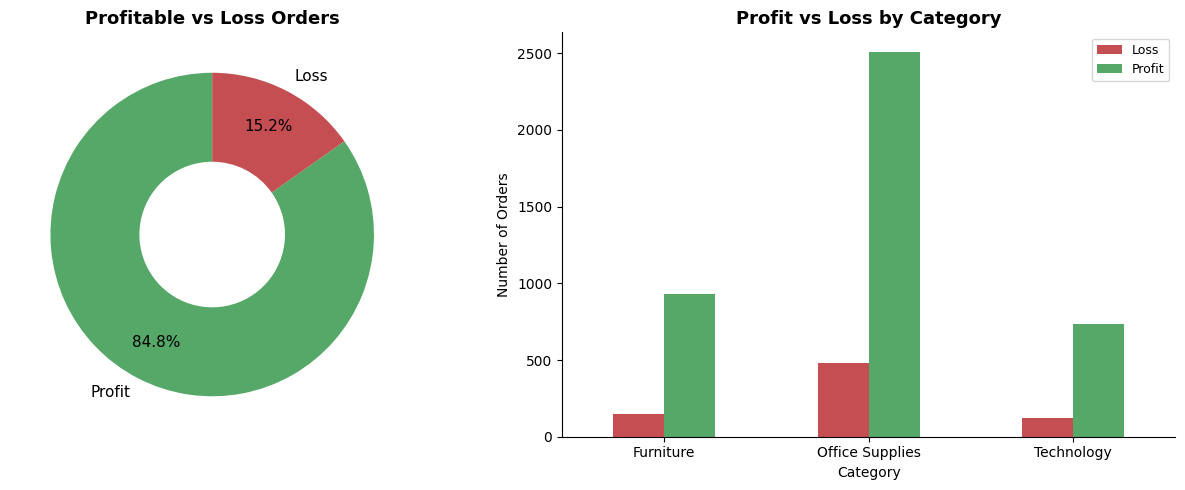

Financial Status breakdown:
  Profit: 4,173 orders (84.8%)
  Loss: 749 orders (15.2%)

By category:
Financial Status  Loss  Profit
Category                      
Furniture          150     929
Office Supplies    479    2511
Technology         120     733


In [29]:
fin = df['Financial Status'].value_counts()
profit_by_cat = df.groupby(['Category', 'Financial Status']).size().unstack(fill_value=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.pie(fin.values, labels=fin.index, colors=[GREEN, ORANGE],
        autopct='%1.1f%%', startangle=90, wedgeprops={'width': 0.55},
        pctdistance=0.75, textprops={'fontsize': 11})
ax1.set_title('Profitable vs Loss Orders', fontsize=13, fontweight='bold')

profit_by_cat.plot(kind='bar', ax=ax2, color=[ORANGE, GREEN], width=0.5)
ax2.set_title('Profit vs Loss by Category', fontsize=13, fontweight='bold')
ax2.set_ylabel('Number of Orders')
ax2.tick_params(axis='x', rotation=0)
ax2.legend(['Loss', 'Profit'], fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print("Financial Status breakdown:")
for status, count in fin.items():
    print(f"  {status}: {count:,} orders ({count/len(df)*100:.1f}%)")
print()
print("By category:")
print(profit_by_cat)

### Insight
A significant portion of orders result in a loss, which is a concern for the business. Furniture has the highest proportion of loss-making orders, often due to heavy discounts. The store should review its discounting strategy, especially for Furniture products.


## Q10 — How does discount affect profit?

Higher discounts might attract more customers but could hurt profitability.


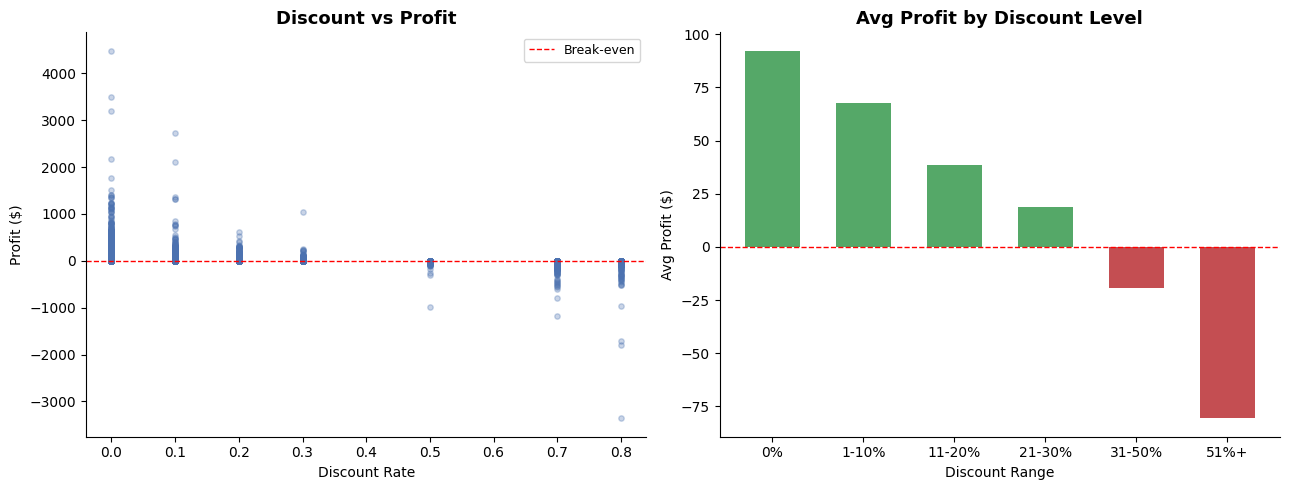

Avg profit by discount level:
Discount Bucket
0%        92.26
1-10%     67.62
11-20%    38.46
21-30%    18.94
31-50%   -19.38
51%+     -80.61
Name: Profit, dtype: float64


In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.scatter(df['Discount'], df['Profit'], alpha=0.3, color=BLUE, s=15)
ax1.axhline(0, color='red', linewidth=1, linestyle='--', label='Break-even')
ax1.set_title('Discount vs Profit', fontsize=13, fontweight='bold')
ax1.set_xlabel('Discount Rate')
ax1.set_ylabel('Profit ($)')
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

df['Discount Bucket'] = pd.cut(df['Discount'],
                                bins=[-0.01, 0, 0.1, 0.2, 0.3, 0.5, 0.9],
                                labels=['0%','1-10%','11-20%','21-30%','31-50%','51%+'])
disc_profit = df.groupby('Discount Bucket', observed=True)['Profit'].mean()
colors_bar  = [GREEN if v > 0 else ORANGE for v in disc_profit.values]
ax2.bar(disc_profit.index, disc_profit.values, color=colors_bar, width=0.6)
ax2.axhline(0, color='red', linewidth=1, linestyle='--')
ax2.set_title('Avg Profit by Discount Level', fontsize=13, fontweight='bold')
ax2.set_xlabel('Discount Range')
ax2.set_ylabel('Avg Profit ($)')
ax2.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print("Avg profit by discount level:")
print(disc_profit.round(2))

### Insight
There is a clear negative relationship between discount and profit. Orders with no discount or very low discounts tend to be profitable, while orders with discounts above 30% frequently result in losses. The store should set a maximum discount policy to protect profit margins.


## Full Dashboard

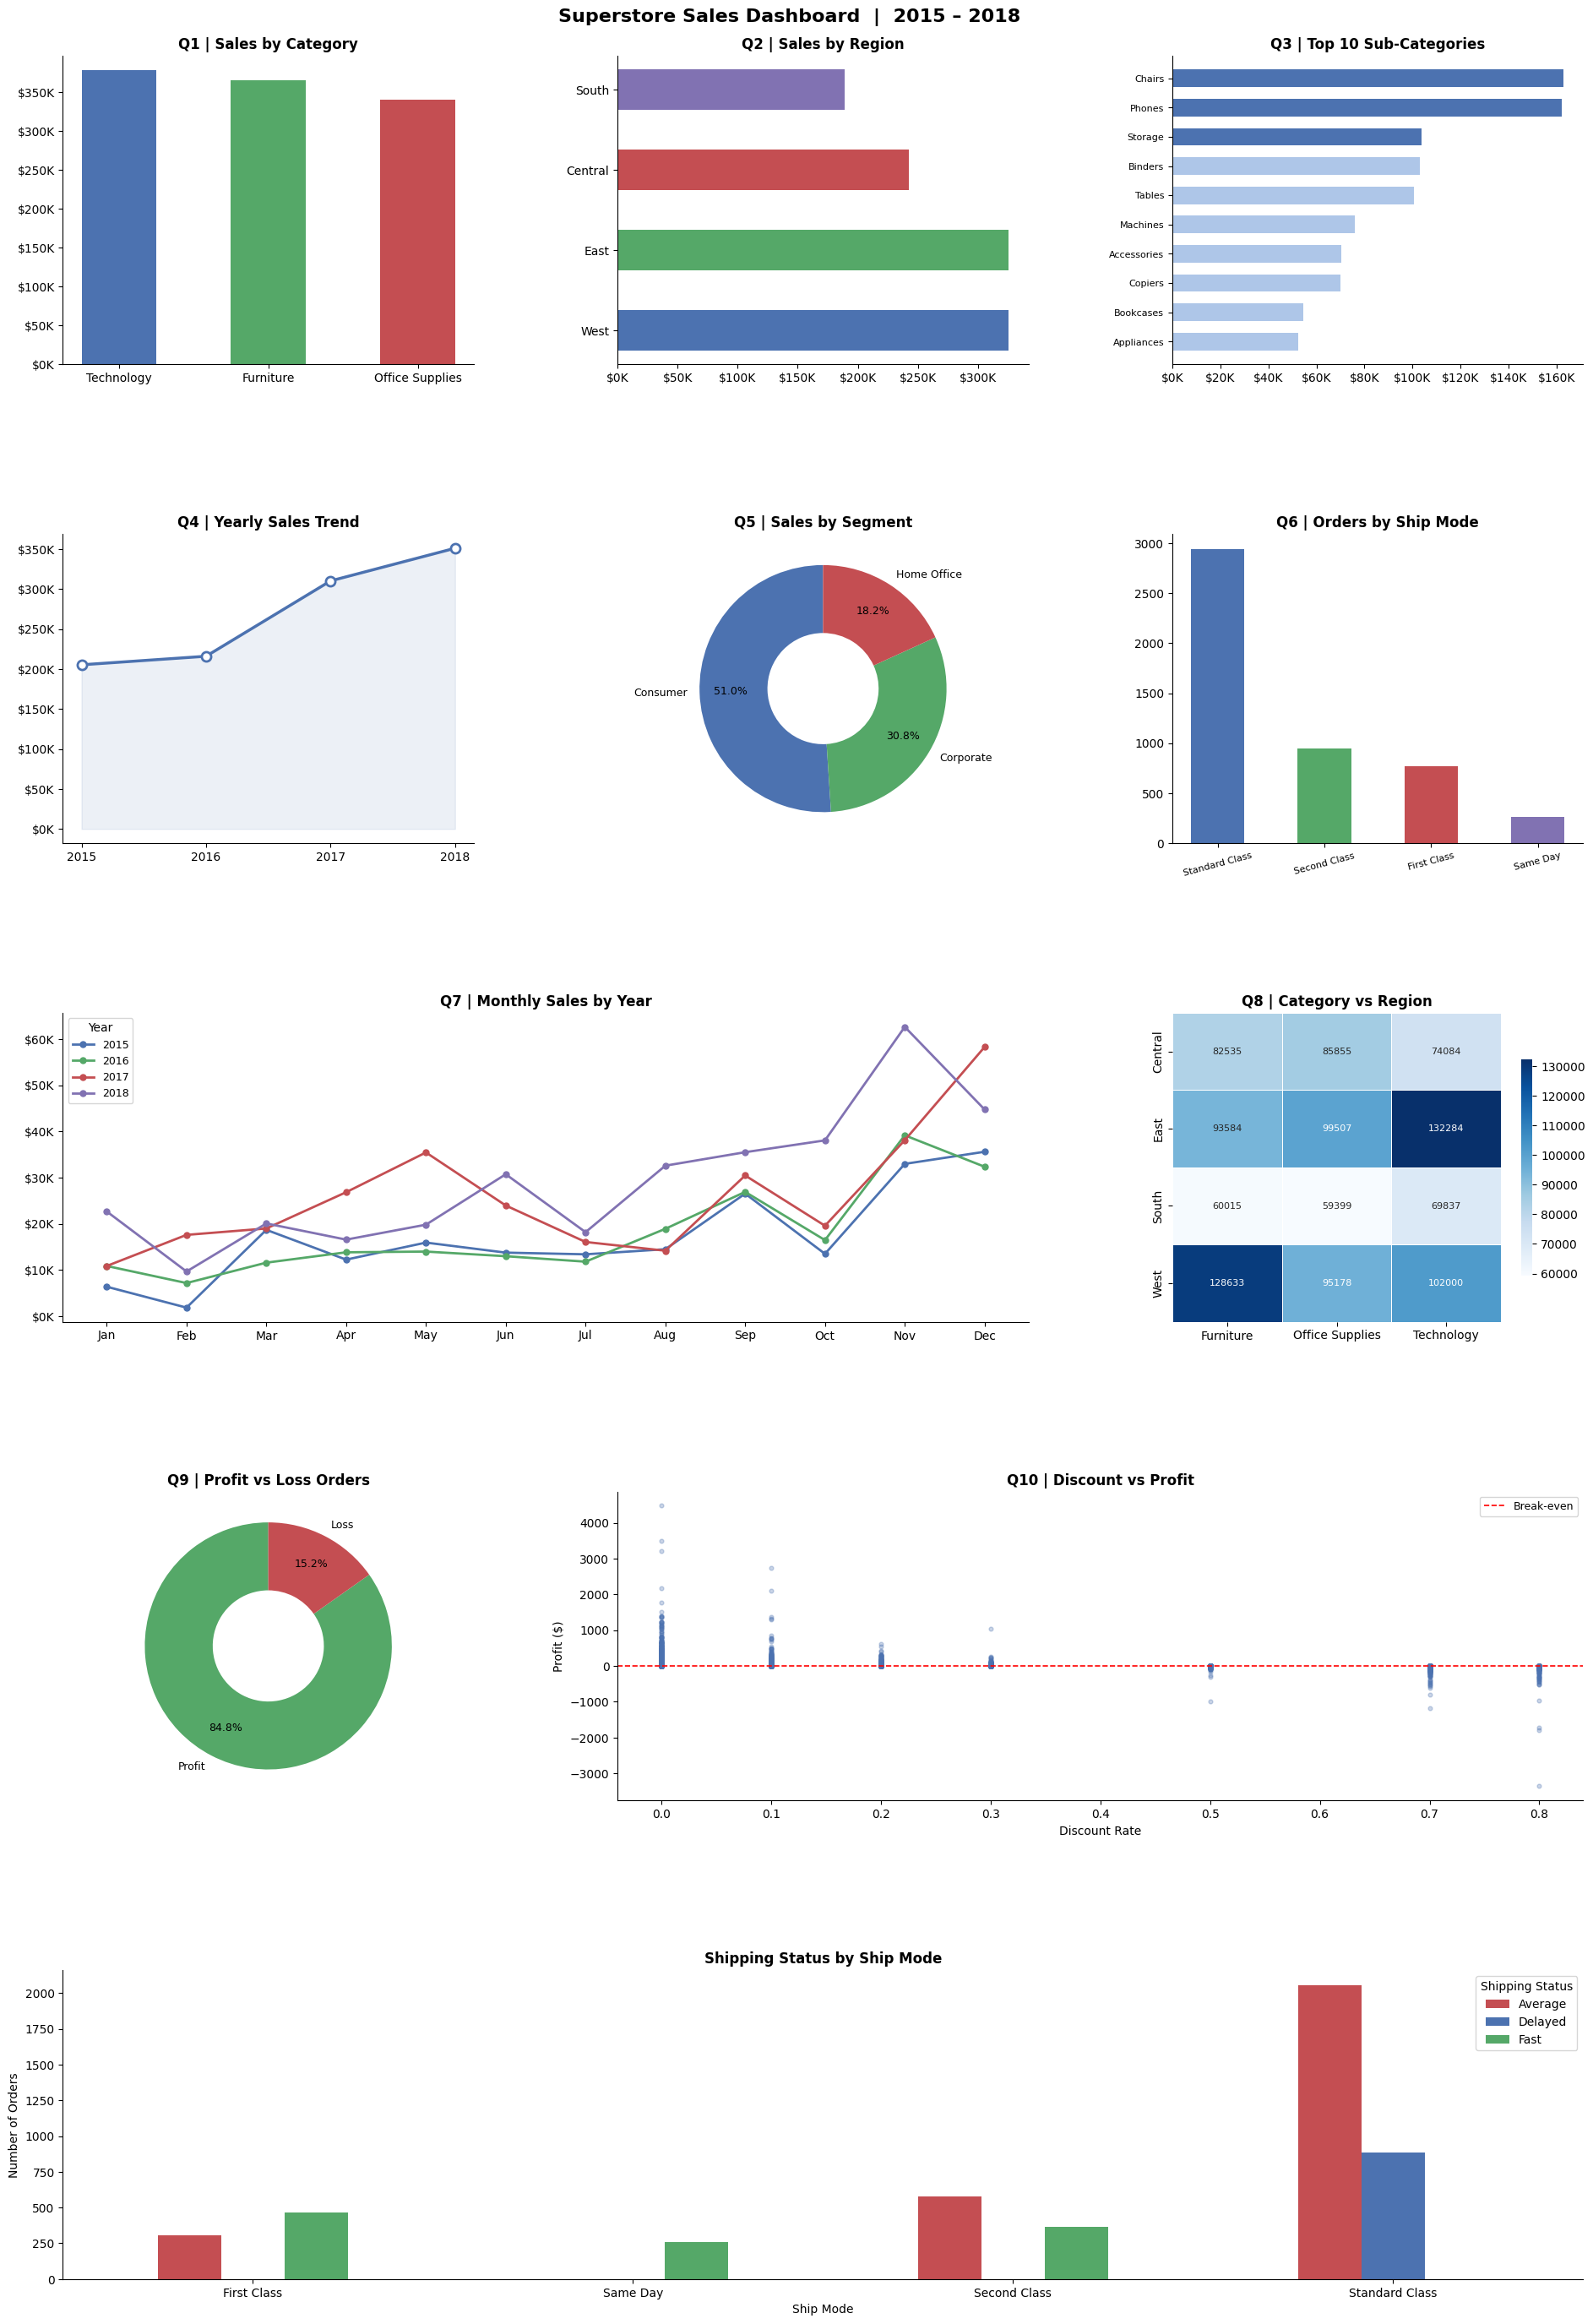

Dashboard saved.


In [31]:
fig = plt.figure(figsize=(20, 28))
fig.suptitle('Superstore Sales Dashboard  |  2015 – 2018',
             fontsize=16, fontweight='bold', y=0.99)
gs = fig.add_gridspec(5, 3, hspace=0.55, wspace=0.35,
                       left=0.07, right=0.97, top=0.97, bottom=0.03)

ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(cat_sales.index, cat_sales.values, color=[BLUE, GREEN, ORANGE], width=0.5)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
ax1.set_title('Q1 | Sales by Category', fontweight='bold')
ax1.spines[['top','right']].set_visible(False)

ax2 = fig.add_subplot(gs[0, 1])
ax2.barh(region_sales.index, region_sales.values, color=[BLUE,GREEN,ORANGE,PURPLE], height=0.5)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
ax2.set_title('Q2 | Sales by Region', fontweight='bold')
ax2.spines[['top','right']].set_visible(False)

ax3 = fig.add_subplot(gs[0, 2])
bar_c = [BLUE if i < 3 else '#aec6e8' for i in range(len(top10))]
ax3.barh(top10.index[::-1], top10.values[::-1], color=bar_c[::-1], height=0.6)
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
ax3.set_title('Q3 | Top 10 Sub-Categories', fontweight='bold')
ax3.tick_params(axis='y', labelsize=8)
ax3.spines[['top','right']].set_visible(False)

ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(yr.index, yr.values, color=BLUE, linewidth=2.5, marker='o', markersize=8,
         markerfacecolor='white', markeredgecolor=BLUE, markeredgewidth=2)
ax4.fill_between(yr.index, yr.values, alpha=0.1, color=BLUE)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
ax4.set_title('Q4 | Yearly Sales Trend', fontweight='bold')
ax4.set_xticks(yr.index)
ax4.spines[['top','right']].set_visible(False)

ax5 = fig.add_subplot(gs[1, 1])
ax5.pie(seg.values, labels=seg.index, colors=[BLUE, GREEN, ORANGE],
        autopct='%1.1f%%', startangle=90, wedgeprops={'width': 0.55},
        pctdistance=0.75, textprops={'fontsize': 9})
ax5.set_title('Q5 | Sales by Segment', fontweight='bold')

ax6 = fig.add_subplot(gs[1, 2])
ship_mode_count = df['Ship Mode'].value_counts()
ax6.bar(ship_mode_count.index, ship_mode_count.values, color=[BLUE,GREEN,ORANGE,PURPLE], width=0.5)
ax6.set_title('Q6 | Orders by Ship Mode', fontweight='bold')
ax6.tick_params(axis='x', rotation=15, labelsize=8)
ax6.spines[['top','right']].set_visible(False)

ax7 = fig.add_subplot(gs[2, :2])
for i, yr_val in enumerate(sorted(df['Year'].unique())):
    subset = month_year[month_year['Year'] == yr_val]
    ax7.plot(subset['Month'], subset['Sales'], label=str(yr_val),
             color=year_colors[i], linewidth=2, marker='o', markersize=5)
ax7.set_xticks(range(1,13))
ax7.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax7.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
ax7.legend(title='Year', fontsize=9)
ax7.set_title('Q7 | Monthly Sales by Year', fontweight='bold')
ax7.spines[['top','right']].set_visible(False)

ax8 = fig.add_subplot(gs[2, 2])
sns.heatmap(hm, ax=ax8, cmap='Blues', annot=True, fmt='.0f',
            linewidths=0.5, annot_kws={'size': 8}, cbar_kws={'shrink': 0.7})
ax8.set_title('Q8 | Category vs Region', fontweight='bold')
ax8.set_xlabel(''); ax8.set_ylabel('')

ax9 = fig.add_subplot(gs[3, 0])
fin = df['Financial Status'].value_counts()
ax9.pie(fin.values, labels=fin.index, colors=[GREEN, ORANGE],
        autopct='%1.1f%%', startangle=90, wedgeprops={'width': 0.55},
        pctdistance=0.75, textprops={'fontsize': 9})
ax9.set_title('Q9 | Profit vs Loss Orders', fontweight='bold')

ax10 = fig.add_subplot(gs[3, 1:])
ax10.scatter(df['Discount'], df['Profit'], alpha=0.3, color=BLUE, s=12)
ax10.axhline(0, color='red', linewidth=1.2, linestyle='--', label='Break-even')
ax10.set_title('Q10 | Discount vs Profit', fontweight='bold')
ax10.set_xlabel('Discount Rate'); ax10.set_ylabel('Profit ($)')
ax10.legend(fontsize=9)
ax10.spines[['top','right']].set_visible(False)

ax11 = fig.add_subplot(gs[4, :])
ship_status = df.groupby(['Ship Mode', 'Shipping Status']).size().unstack(fill_value=0)
ship_status.plot(kind='bar', ax=ax11, color=[ORANGE, BLUE, GREEN], width=0.5)
ax11.set_title('Shipping Status by Ship Mode', fontweight='bold')
ax11.set_ylabel('Number of Orders')
ax11.tick_params(axis='x', rotation=0)
ax11.spines[['top','right']].set_visible(False)

plt.savefig('superstore_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved.")

## Conclusion & Business Recommendations

### Key Findings
| # | Finding |
|---|---------|
| 1 | Technology is the highest-revenue category |
| 2 | The West region leads all regions in sales |
| 3 | Sales have grown consistently from 2015 to 2018 |
| 4 | Consumer segment drives over 50% of all revenue |
| 5 | Standard Class is the most used shipping method despite being the slowest |
| 6 | November is consistently the peak sales month |
| 7 | The South region underperforms across all categories |
| 8 | High discounts (above 30%) consistently lead to losses |

---

### Business Recommendations

**1. Focus on Technology products**
Technology generates the most revenue. The store should prioritize stocking popular tech products and running targeted campaigns in this category.

**2. Invest in the South region**
The South consistently underperforms. A dedicated marketing budget and regional promotions could help close the gap with the West and East.

**3. Prepare for the November peak**
Sales spike every November due to the holiday season. The store should plan inventory and staffing in advance to avoid stockouts and delays.

**4. Control the discounting strategy**
Orders with discounts above 30% frequently result in losses. The store should set a maximum discount cap to protect profit margins.

**5. Promote faster shipping for key customers**
Most customers use Standard Class (slowest). Offering First Class as an upgrade for Consumer segment customers could improve satisfaction and loyalty.


## Summary Table

In [32]:
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

summary = {
    'Question': [
        'Q1 - Top Category', 'Q2 - Top Region', 'Q3 - Top Sub-Category',
        'Q4 - Sales Growth', 'Q5 - Top Segment', 'Q6 - Fastest Shipping',
        'Q6 - Most Used Shipping', 'Q7 - Best Sales Month',
        'Q9 - Profitable Orders', 'Total Revenue', 'Total Profit',
        'Total Orders', 'Unique Customers'
    ],
    'Answer': [
        cat_sales.idxmax(),
        region_sales.idxmax(),
        subcat.idxmax(),
        f"{((yr.iloc[-1]-yr.iloc[0])/yr.iloc[0]*100):.1f}% growth",
        f"{seg.idxmax()} ({seg.max()/seg.sum()*100:.1f}%)",
        f"{ship_avg.idxmin()} ({ship_avg.min():.1f} days)",
        f"{ship_count.idxmax()} ({ship_count.max():,} orders)",
        month_labels[mon_total.idxmax()-1],
        f"{(df['Financial Status']=='Profit').sum():,} ({(df['Financial Status']=='Profit').mean()*100:.1f}%)",
        f"${df['Sales'].sum():,.2f}",
        f"${df['Profit'].sum():,.2f}",
        f"{df['Order ID'].nunique():,}",
        f"{df['Customer ID'].nunique():,}"
    ]
}

summary_df = pd.DataFrame(summary)
summary_df.to_csv('analysis_summary.csv', index=False)
summary_df

,Question,Answer
0,Q1 - Top Category,Technology
1,Q2 - Top Region,West
2,Q3 - Top Sub-Category,Chairs
3,Q4 - Sales Growth,71.0% growth
4,Q5 - Top Segment,Consumer (51.0%)
5,Q6 - Fastest Shipping,Same Day (0.0 days)
6,Q6 - Most Used Shipping,"Standard Class (2,945 orders)"
7,Q7 - Best Sales Month,Nov
8,Q9 - Profitable Orders,"4,173 (84.8%)"
9,Total Revenue,"$1,082,910.83"
